# RELDEC Reward Comparison: Default vs Hard Syndrome

This notebook compares BER vs SNR for two RELDEC training rewards:
1. Default reward from `ReldecEnv` (Eq. 5, bit-match against transmitted codeword).
2. Custom hard-syndrome reward (proportion of satisfied checks in the scheduled cluster).

In [1]:
import os
import sys
import time
import random
import numpy as np
import matplotlib.pyplot as plt

nb_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(nb_dir, '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from ldpc.bp_decoder import BpDecoder
from utils.LDPC_encode import QCLDPCEncoder
from utils.awgn_channel import AWGNChannel
from reldec.reldec_env import ReldecEnv
from reldec.q_agent import QAgent
from reldec.decoder import ReldecDecoder

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
print('Using project root:', project_root)

Using project root: /Users/rithvik/Documents/hnrs/Decoder


In [2]:
def load_base_matrix(path: str) -> np.ndarray:
    rows = []
    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append([int(x) for x in line.split()])
    return np.array(rows, dtype=int)


def generate_data(encoder: QCLDPCEncoder, n_frames: int, snr_db: float, seed: int):
    rng = np.random.RandomState(seed)
    messages = rng.randint(0, 2, size=(n_frames, encoder.K))
    codewords = encoder.encode(messages)
    bpsk = 1.0 - 2.0 * codewords.astype(np.float64)
    llr_matrix = AWGNChannel(bpsk, snr_db)
    return codewords, llr_matrix

In [3]:
base_matrix_path = os.path.join(project_root, 'pc_matrices', 'small_16.txt')
base_matrix = load_base_matrix(base_matrix_path)
Z = 11

encoder = QCLDPCEncoder(base_matrix, Z)
H = encoder.H
m, n = H.shape

clusters = [[i] for i in range(m)]

print(f'H shape: {H.shape}, K={encoder.K}, rate={encoder.K / encoder.N:.3f}')
print(f'Clusters: {len(clusters)} (z=1)')

Initializing Encoder: Full Matrix Size 66x198, Message Bits: 132
  > Inverting Parity Matrix (this may take a moment for large Z)...
  > Computing Generator Matrix...
Encoder Ready.
H shape: (66, 198), K=132, rate=0.667
Clusters: 66 (z=1)


## Hard-Syndrome Reward
For scheduled cluster $C_a$, define
$$R_a = 1 - rac{1}{|C_a|}um_{c n C_a} s_c$$
where $s_c = 0$ if check $c$ is satisfied under hard decisions, else $1$.

In [4]:
def make_hard_syndrome_reward(H: np.ndarray, clusters):
    H_int = np.asarray(H, dtype=np.int32)

    def hard_syndrome_reward(cluster_idx, vns, current_llrs, transmitted_codeword):
        cluster_cns = np.asarray(clusters[cluster_idx], dtype=np.int32)
        if len(cluster_cns) == 0:
            return 0.0

        x_hat = (np.asarray(current_llrs) < 0).astype(np.int32)
        local_syndrome = (H_int[cluster_cns] @ x_hat) % 2
        return float(1.0 - np.mean(local_syndrome))

    return hard_syndrome_reward


class LLRConfidenceGainReward:
    def __init__(self, clip_value: float = 5.0):
        self.clip_value = clip_value
        self.prev_llrs = None

    def reset(self):
        self.prev_llrs = None

    def __call__(self, cluster_idx, vns, current_llrs, transmitted_codeword):
        if len(vns) == 0:
            return 0.0

        current_llrs = np.asarray(current_llrs, dtype=np.float64)
        if self.prev_llrs is None:
            self.prev_llrs = current_llrs.copy()
            return 0.0

        gain = np.mean(np.abs(current_llrs[vns]) - np.abs(self.prev_llrs[vns]))
        self.prev_llrs = current_llrs.copy()
        return float(np.clip(gain, -self.clip_value, self.clip_value))


def make_llr_confidence_gain_reward(clip_value: float = 5.0):
    return LLRConfidenceGainReward(clip_value=clip_value)

In [5]:
# Training and evaluation setup
TRAIN_SNR_DB = 4.0
N_TRAIN = 80
N_TEST = 200
I_MAX = 30
SNR_GRID = [2.0, 3.0, 4.0, 5.0, 6.0]

ALPHA = 0.5
BETA = 0.9
EPSILON = 0.1

train_codewords, train_llrs = generate_data(
    encoder, n_frames=N_TRAIN, snr_db=TRAIN_SNR_DB, seed=123
)

train_llr_list = [train_llrs[i] for i in range(N_TRAIN)]
train_cw_list = [train_codewords[i] for i in range(N_TRAIN)]

print('Training frames ready:', len(train_llr_list))

Training frames ready: 80


In [6]:
def train_reldec_agent(H, clusters, llr_list, codeword_list, reward_fn=None):
    bp_for_env = BpDecoder(H, max_iter=0, bp_method='product_sum', schedule='parallel')
    env = ReldecEnv(H, clusters, bp_for_env, l_max=len(clusters), reward_fn=reward_fn)

    if reward_fn is not None and hasattr(reward_fn, 'reset'):
        original_reset = env.reset

        def reset_with_reward(*args, **kwargs):
            reward_fn.reset()
            return original_reset(*args, **kwargs)

        env.reset = reset_with_reward

    agent = QAgent(
        num_clusters=len(clusters),
        alpha=ALPHA,
        beta=BETA,
        epsilon=EPSILON,
    )

    t0 = time.time()
    rewards = agent.train(
        env,
        llr_list=llr_list,
        codeword_list=codeword_list,
        verbose=True,
    )
    elapsed = time.time() - t0

    bp_for_decode = BpDecoder(H, max_iter=0, bp_method='product_sum', schedule='parallel')
    decoder = ReldecDecoder(H, clusters, bp_for_decode, agent)
    return decoder, rewards, elapsed

print('Training DEFAULT reward RELDEC...')
reldec_default, rewards_default, t_default = train_reldec_agent(
    H, clusters, train_llr_list, train_cw_list, reward_fn=None
)

print('Training HARD-SYNDROME reward RELDEC...')
hard_reward_fn = make_hard_syndrome_reward(H, clusters)
reldec_hs, rewards_hs, t_hs = train_reldec_agent(
    H, clusters, train_llr_list, train_cw_list, reward_fn=hard_reward_fn
)

print('Training LLR-CONFIDENCE-GAIN reward RELDEC...')
llr_gain_reward_fn = make_llr_confidence_gain_reward(clip_value=5.0)
reldec_llr_gain, rewards_llr_gain, t_llr_gain = train_reldec_agent(
    H, clusters, train_llr_list, train_cw_list, reward_fn=llr_gain_reward_fn
)

print(f'Default reward training time: {t_default:.1f}s')
print(f'Hard-syndrome training time: {t_hs:.1f}s')
print(f'LLR-confidence-gain training time: {t_llr_gain:.1f}s')

Training DEFAULT reward RELDEC...
  Episode 8/80 | Avg reward (recent): 0.9621
  Episode 16/80 | Avg reward (recent): 0.9957
  Episode 24/80 | Avg reward (recent): 0.9466
  Episode 32/80 | Avg reward (recent): 0.9981
  Episode 40/80 | Avg reward (recent): 0.9682
  Episode 48/80 | Avg reward (recent): 0.9957
  Episode 56/80 | Avg reward (recent): 0.9958
  Episode 64/80 | Avg reward (recent): 0.9972
  Episode 72/80 | Avg reward (recent): 0.9925
  Episode 80/80 | Avg reward (recent): 0.9968
Training HARD-SYNDROME reward RELDEC...
  Episode 8/80 | Avg reward (recent): 0.9905
  Episode 16/80 | Avg reward (recent): 0.9962
  Episode 24/80 | Avg reward (recent): 0.9962
  Episode 32/80 | Avg reward (recent): 0.9943
  Episode 40/80 | Avg reward (recent): 0.9924
  Episode 48/80 | Avg reward (recent): 0.9924
  Episode 56/80 | Avg reward (recent): 0.9962
  Episode 64/80 | Avg reward (recent): 0.9905
  Episode 72/80 | Avg reward (recent): 0.9943
  Episode 80/80 | Avg reward (recent): 0.9924
Training

In [7]:
def eval_decoder_ber(decoder, codewords, llrs, i_max=30):
    total_errors = 0
    total_bits = codewords.shape[0] * codewords.shape[1]
    for i in range(codewords.shape[0]):
        decoded = decoder.decode(llrs[i], I_max=i_max)
        total_errors += int(np.sum(decoded != codewords[i]))
    return total_errors / total_bits

bers_default = []
bers_hs = []
bers_llr_gain = []

print(f'{"SNR":>6} | {"BER Default":>12} | {"BER Hard-Syn":>12} | {"BER LLR-Gain":>12}')
print('-' * 58)

for snr_db in SNR_GRID:
    test_codewords, test_llrs = generate_data(
        encoder, n_frames=N_TEST, snr_db=snr_db, seed=int(1000 * snr_db)
    )

    ber_default = eval_decoder_ber(reldec_default, test_codewords, test_llrs, i_max=I_MAX)
    ber_hs = eval_decoder_ber(reldec_hs, test_codewords, test_llrs, i_max=I_MAX)
    ber_llr_gain = eval_decoder_ber(reldec_llr_gain, test_codewords, test_llrs, i_max=I_MAX)

    bers_default.append(ber_default)
    bers_hs.append(ber_hs)
    bers_llr_gain.append(ber_llr_gain)

    print(f'{snr_db:6.1f} | {ber_default:12.4e} | {ber_hs:12.4e} | {ber_llr_gain:12.4e}')

   SNR |  BER Default | BER Hard-Syn | BER LLR-Gain
----------------------------------------------------------
   2.0 |   7.3030e-02 |   7.3030e-02 |   7.3081e-02
   3.0 |   3.1843e-02 |   3.1086e-02 |   3.2020e-02
   4.0 |   5.1515e-03 |   5.4545e-03 |   5.4040e-03
   5.0 |   9.5960e-04 |   7.5758e-04 |   1.0354e-03
   6.0 |   1.0101e-04 |   1.0101e-04 |   1.0101e-04


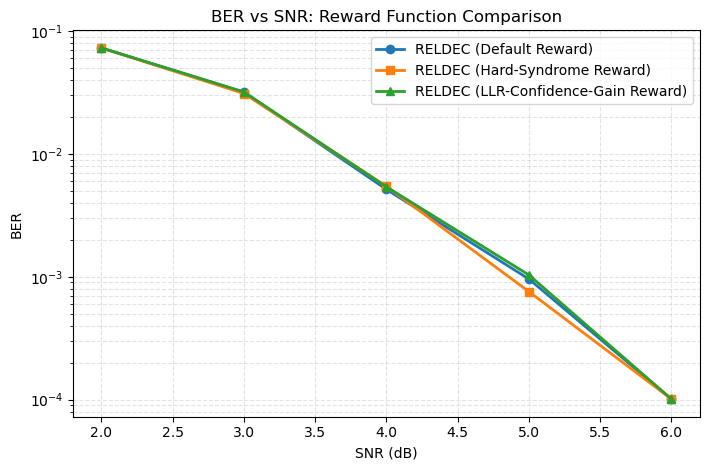

In [8]:
plt.figure(figsize=(7.2, 4.8))
plt.semilogy(SNR_GRID, bers_default, marker='o', linewidth=2, label='RELDEC (Default Reward)')
plt.semilogy(SNR_GRID, bers_hs, marker='s', linewidth=2, label='RELDEC (Hard-Syndrome Reward)')
plt.semilogy(SNR_GRID, bers_llr_gain, marker='^', linewidth=2, label='RELDEC (LLR-Confidence-Gain Reward)')
plt.grid(True, which='both', linestyle='--', alpha=0.35)
plt.xlabel('SNR (dB)')
plt.ylabel('BER')
plt.title('BER vs SNR: Reward Function Comparison')
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
print('SNR grid:', SNR_GRID)
print('BER default        :', [float(x) for x in bers_default])
print('BER hard syndrome  :', [float(x) for x in bers_hs])
print('BER llr confidence :', [float(x) for x in bers_llr_gain])

SNR grid: [2.0, 3.0, 4.0, 5.0, 6.0]
BER default        : [0.07303030303030303, 0.03184343434343434, 0.005151515151515152, 0.0009595959595959596, 0.00010101010101010101]
BER hard syndrome  : [0.07303030303030303, 0.031085858585858585, 0.005454545454545455, 0.0007575757575757576, 0.00010101010101010101]
BER llr confidence : [0.07308080808080808, 0.03202020202020202, 0.005404040404040404, 0.0010353535353535353, 0.00010101010101010101]
